In [23]:
from datetime import datetime
import rasterio
import numpy as np
import pandas as pd
import os
from loguru import logger
from glob import glob
import json

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from pyproj import Transformer

In [2]:
# for fn in os.listdir("colorado-sentinel"):
#     if fn.endswith(".VZA.tif"):
#         fp = os.path.join("colorado-sentinel", fn)
#         os.remove(fp)

# for fn in os.listdir("hls-sentinel"):
#     if fn.endswith(".VZA.tif"):
#         fp = os.path.join("hls-sentinel", fn)
#         os.remove(fp)

In [5]:
tile_ids = []
for fp in os.listdir("usa-sentinel"):
    if not fp.endswith(".Fmask.tif"):
        continue
    tile_id = fp.split(".")[2]
    tile_ids.append(tile_id)
len(tile_ids), len(np.unique(tile_ids))

(344, 344)

In [6]:
tile_ids = []
for fp in os.listdir("usa-opera"):
    if not fp.endswith("_WTR.tif"):
        continue
    tile_id = fp.split("_")[-8]
    tile_ids.append(tile_id)
len(tile_ids), len(np.unique(tile_ids))

(1200, 810)

In [11]:
# Find all relevant opera tiles
ctr = 0
opera_files_with_match = []
opera_hls_mapping = {}
for fp_opera in os.listdir("usa-opera"):
    if not fp_opera.endswith("_WTR.tif"):
        continue
    opera_sat = fp_opera.split("_")[-5]
    opera_tile_id = fp_opera.split("_")[-8]
    opera_datetime = fp_opera.split("_")[-7]
    opera_year = opera_datetime[:4]
    opera_date = opera_datetime.split("T")[0]
    datetime_object = datetime.strptime(opera_date, '%Y%m%d')
    opera_day_of_year = datetime_object.timetuple().tm_yday

    hls_date = f"{opera_year}{opera_day_of_year}"
    
    if opera_sat == "L8": # landsat
        sat_dir = "usa-landsat"
    else:
        sat_dir = "usa-sentinel"
    # sat_files = glob(os.path.join(sat_dir, f"*.{opera_tile_id}.{hls_date}*"))
    sat_files = glob(os.path.join(sat_dir, f"*.{opera_tile_id}.*"))
    if len(sat_files)>0:
        opera_hls_mapping[fp_opera] = sat_files
        opera_files_with_match.append(fp_opera)
        ctr += 1
        logger.debug(f"[{len(sat_files)}]. opera_sat: {opera_sat}, opera_tile_id: {opera_tile_id}, opera_year: {opera_year}, opera_day_of_year: {opera_day_of_year}. hls_date: {hls_date}")
        # break
logger.debug(f"Found {ctr} matched opera files")

2024-02-08 14:53:13.790 | DEBUG    | __main__:<module>:28 - [18]. opera_sat: S2A, opera_tile_id: T10TEQ, opera_year: 2023, opera_day_of_year: 162. hls_date: 2023162
2024-02-08 14:53:13.819 | DEBUG    | __main__:<module>:28 - [18]. opera_sat: S2A, opera_tile_id: T10TER, opera_year: 2023, opera_day_of_year: 162. hls_date: 2023162
2024-02-08 14:53:13.850 | DEBUG    | __main__:<module>:28 - [18]. opera_sat: S2A, opera_tile_id: T10TES, opera_year: 2023, opera_day_of_year: 162. hls_date: 2023162
2024-02-08 14:53:13.881 | DEBUG    | __main__:<module>:28 - [18]. opera_sat: S2A, opera_tile_id: T10TET, opera_year: 2023, opera_day_of_year: 162. hls_date: 2023162
2024-02-08 14:53:13.966 | DEBUG    | __main__:<module>:28 - [18]. opera_sat: S2A, opera_tile_id: T10TFM, opera_year: 2023, opera_day_of_year: 162. hls_date: 2023162
2024-02-08 14:53:13.995 | DEBUG    | __main__:<module>:28 - [18]. opera_sat: S2A, opera_tile_id: T10TFN, opera_year: 2023, opera_day_of_year: 162. hls_date: 2023162
2024-02-08

In [15]:

with open("usa_opera_hls_mapping.json", "w") as f:
    json.dump(opera_hls_mapping, f, indent=4)

In [56]:
fp = os.path.join("usa-opera", "OPERA_L3_DSWx-HLS_T10TFR_20230611T185921Z_20230613T205434Z_S2A_30_v1.0_B01_WTR.tif")
data = rasterio.open(os.path.join("usa-opera", k)).read(1)
water = np.where(data==1, 1, 0) + np.where(data==2, 1, 0) + np.where(data==254, 1, 0)
water_gt = np.where(water>0, 1, 0)
plt.imshow(water_gt, cmap="gray")

In [55]:
for k in opera_hls_mapping.keys():
    data = rasterio.open(os.path.join("usa-opera", k)).read(1)
    water = np.where(data==1, 1, 0) + np.where(data==2, 1, 0) + np.where(data==254, 1, 0)
    water_gt = np.where(water>0, 1, 0)
    print(np.sum(water_gt), k)

111848 OPERA_L3_DSWx-HLS_T10TEQ_20230611T185921Z_20230613T205439Z_S2A_30_v1.0_B01_WTR.tif
404352 OPERA_L3_DSWx-HLS_T10TER_20230611T185921Z_20230613T104548Z_S2A_30_v1.0_B01_WTR.tif
180436 OPERA_L3_DSWx-HLS_T10TES_20230611T185921Z_20230613T104545Z_S2A_30_v1.0_B01_WTR.tif
289979 OPERA_L3_DSWx-HLS_T10TET_20230611T185921Z_20230613T205429Z_S2A_30_v1.0_B01_WTR.tif
51384 OPERA_L3_DSWx-HLS_T10TFM_20230611T185921Z_20230613T104502Z_S2A_30_v1.0_B01_WTR.tif
71830 OPERA_L3_DSWx-HLS_T10TFN_20230611T185921Z_20230613T161419Z_S2A_30_v1.0_B01_WTR.tif
78853 OPERA_L3_DSWx-HLS_T10TFP_20230611T185921Z_20230613T205605Z_S2A_30_v1.0_B01_WTR.tif
71956 OPERA_L3_DSWx-HLS_T10TFQ_20230611T185921Z_20230613T205408Z_S2A_30_v1.0_B01_WTR.tif
213246 OPERA_L3_DSWx-HLS_T10TFR_20230611T185921Z_20230613T205434Z_S2A_30_v1.0_B01_WTR.tif
81552 OPERA_L3_DSWx-HLS_T10TFS_20230611T185921Z_20230613T161646Z_S2A_30_v1.0_B01_WTR.tif
96826 OPERA_L3_DSWx-HLS_T10TFT_20230611T185921Z_20230614T002408Z_S2A_30_v1.0_B01_WTR.tif
35511 OPERA_L3_D

KeyboardInterrupt: 

In [50]:
fp="/scratch/workspace/rdaroya_umass_edu-water/github/ssc-integration/usa-opera/OPERA_L3_DSWx-HLS_T10TEQ_20230611T185921Z_20230613T205439Z_S2A_30_v1.0_B01_WTR.tif"

In [51]:
src = rasterio.open(fp)
data = src.read(1)

In [52]:
np.unique(data)

array([  0,   1,   2, 252, 253, 255], dtype=uint8)

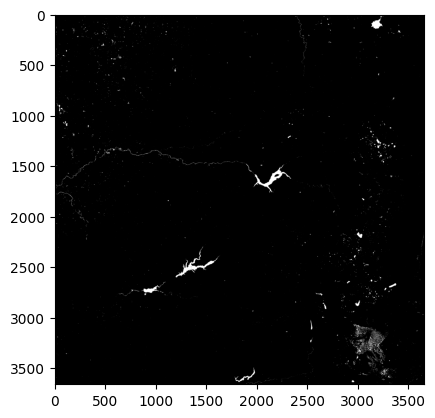

In [53]:

# 1=open water; 2=partial water; 252: snow/ice; 253: Cloud/Cloud Shadow and adjacent to cloud/cloud shadow; 254: Ocean Masked; 0=not water
tmp = np.where(data==1, 1, 0) + np.where(data==2, 1, 0) + np.where(data==254, 1, 0)
water_gt = np.where(tmp>0, 1, 0)
water_gt = water_gt.squeeze()
plt.imshow(water_gt, cmap="gray")